In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal


In [2]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
def impute_with_noise(series):
    series=series.copy()
    non_zero=series[series !=0]
    mu=non_zero.mean()
    sigma=non_zero.std()*0.05
    zero_mask=(series==0)
    noise=np.random.normal(0,sigma,size=zero_mask.sum())
    series[zero_mask]=mu+noise
    return series

In [6]:
df["Glucose"] = impute_with_noise(df["Glucose"])
df["BMI"] = impute_with_noise(df["BMI"])
df["BloodPressure"] = impute_with_noise(df["BloodPressure"])
df["SkinThickness"] = impute_with_noise(df["SkinThickness"])
df["Insulin"] = impute_with_noise(df["Insulin"])


C:\Users\ANUJ\AppData\Local\Temp\ipykernel_11684\3210247966.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[121.38718329 122.08611725 121.58030079 123.19752655 122.5099216 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  series[zero_mask]=mu+noise
C:\Users\ANUJ\AppData\Local\Temp\ipykernel_11684\3210247966.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[72.35987055 71.40661128 71.69281602 72.50839038 74.3935342  72.5305912
 72.96025785 72.80061741 72.30461629 72.79958699 72.42771787 72.27847074
 72.5156753  72.32020175 72.81625444 73.97151069 73.22054358 72.31376439
 73.38354806 71.80334197 72.93101454 73.21516428 70.8093011  72.3396128
 71.83228915 71.90027668 73.2174237  70.9360598  72.11172942 72.8801653
 72.94925843 73.91798685 73.04189691 72.63909096 71.53984629]' h

In [7]:
X=df[["Glucose","BMI"]].values

In [8]:
mean_vector=np.mean(X, axis=0)
cov_matrix=np.cov(X.T)

print("Mean Vector:\n", mean_vector)
print("\nCovariance Matrix:\n", cov_matrix)

Mean Vector:
 [121.68979303  32.45884335]

Covariance Matrix:
 [[926.35117316  48.36239398]
 [ 48.36239398  47.26979584]]


In [9]:
x=np.linspace(X[:,0].min()-10, X[:,0].max()+10,200)
y=np.linspace(X[:,1].min()-10, X[:,1].max()+10,200)
Xg, Yg=np.meshgrid(x,y)

pos=np.dstack((Xg,Yg))
rv=multivariate_normal(mean_vector, cov_matrix)
z=rv.pdf(pos)

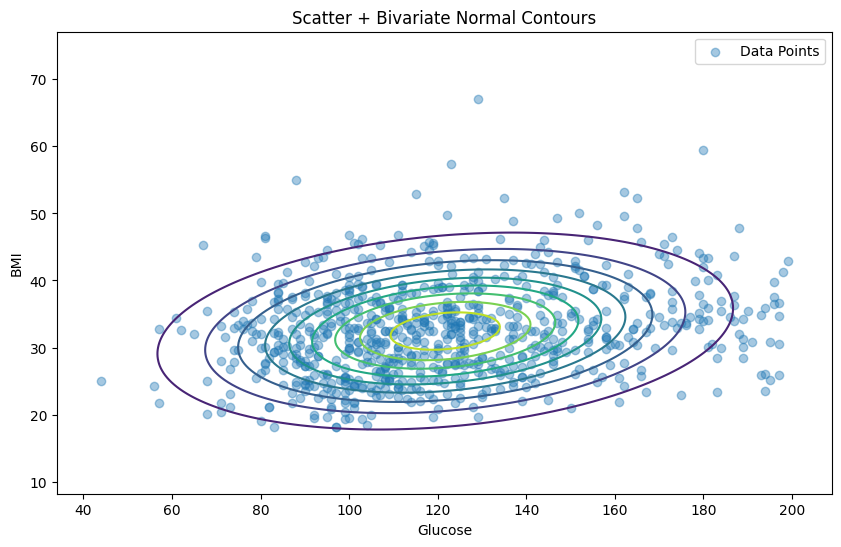

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:,0], X[:,1], alpha=0.4, label="Data Points")
plt.contour(Xg, Yg, z, levels=10, cmap='viridis')
plt.title("Scatter + Bivariate Normal Contours")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.legend()
plt.show()


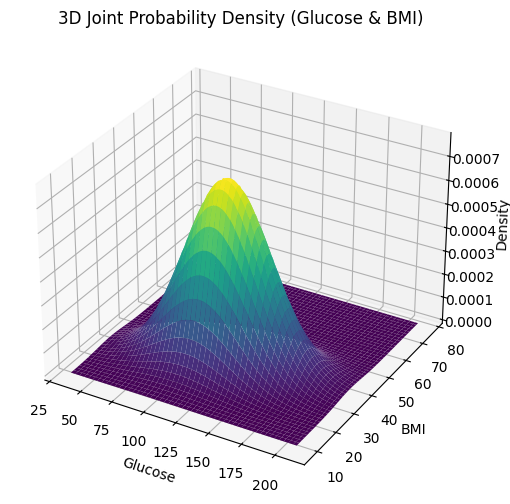

In [13]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(Xg, Yg, z, cmap='viridis', linewidth=0, antialiased=True)
ax.set_title("3D Joint Probability Density (Glucose & BMI)")
ax.set_xlabel("Glucose")
ax.set_ylabel("BMI")
ax.set_zlabel("Density")
plt.show()


In [17]:
df0=df[df["Outcome"]==0]
df1=df[df["Outcome"]==1]

mu0=df0[["Glucose","BMI"]].mean().values
cov0=np.cov(df0[["Glucose","BMI"]].values.T)

mu1=df1[["Glucose","BMI"]].mean().values
cov1=np.cov(df1[["Glucose","BMI"]].values.T)

p0=len(df0)/len(df)
p1=len(df1)/len(df)

mv0= multivariate_normal(mu0, cov0)
mv1= multivariate_normal(mu1, cov1)
            


In [18]:
P=mv1.pdf(pos)*p1/(mv1.pdf(pos)*p1 + mv0.pdf(pos)*p0)

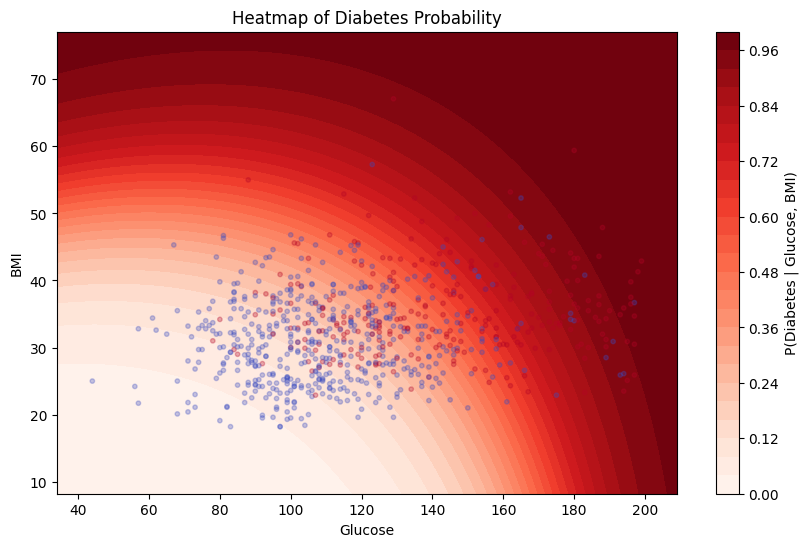

In [19]:
plt.figure(figsize=(10,6))
plt.contourf(Xg, Yg, P, levels=30, cmap='Reds')
plt.colorbar(label="P(Diabetes | Glucose, BMI)")
plt.scatter(X[:,0], X[:,1], s=10, alpha=0.3, c=df["Outcome"], cmap="coolwarm")
plt.title("Heatmap of Diabetes Probability")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()


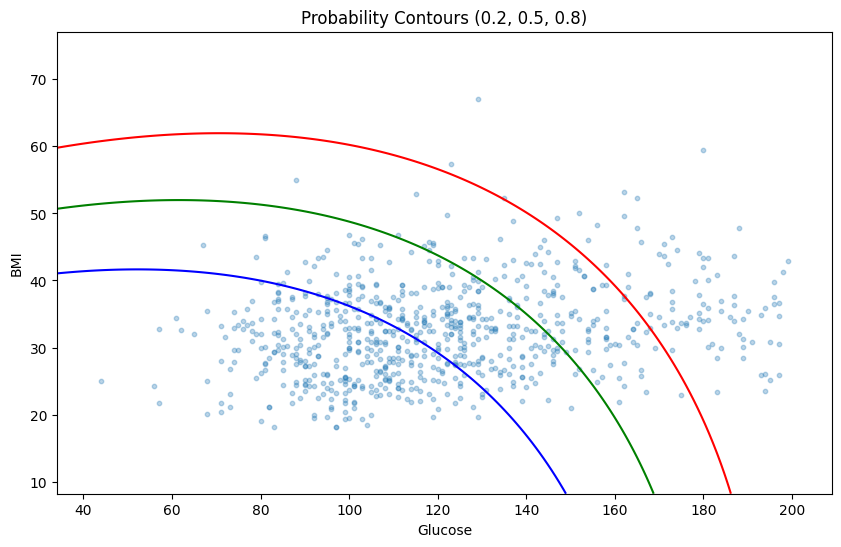

In [20]:
plt.figure(figsize=(10,6))
plt.contour(Xg, Yg, P, levels=[0.2, 0.5, 0.8], colors=['blue','green','red'])
plt.scatter(X[:,0], X[:,1], s=10, alpha=0.3)
plt.title("Probability Contours (0.2, 0.5, 0.8)")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()
